In [6]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [7]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="mxbai-embed-large:latest"
)

In [12]:
from langgraph.graph import StateGraph
from typing import TypedDict,Any

#### 1.Prompt Chaining -Job Application Assistant

In [65]:
class ChainState(TypedDict):
    user_query:str
    job_search:list
    matched_jobs:list
    ranked_jobs:list
    resume_summary:str
    cover_letter:str

##### job search agent

In [66]:
import requests

GREENHOUSE_COMPANIES = [
    "openai",
    "stripe",
    "notion",
    "airbnb",
    "figma",
    "coinbase"
]

def search_jobs_agent(state:ChainState)->ChainState:
    query = state["user_query"]
    jobs = []

    for company in GREENHOUSE_COMPANIES:

        url = (
            f"https://boards-api.greenhouse.io/v1/"
            f"boards/{company}/jobs?content=true"
        )

        response = requests.get(url)

        if response.status_code != 200:
            continue

        data = response.json()

        for job in data["jobs"]:

            title = job["title"].lower()

            if query in title:

                jobs.append({
                    "company": company,
                    "title": job["title"],
                    "location": job["location"]["name"],
                    "url": job["absolute_url"],
                    "description": job["content"]
                })

    return {**state,"job_search":jobs}

##### matching agent

In [67]:
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore

def matching_agent(state: ChainState) -> ChainState:

    client = QdrantClient(path="./qdrant_db")

    vector_store = QdrantVectorStore(
        client=client,
        collection_name="resume",
        embedding=embedding_model
    )

    matched_jobs = []

    for job in state["job_search"]:

        docs = vector_store.similarity_search_with_score(
            job["description"],
            k=4
        )
        
        context = "\n\n".join(
            
            f"""
            Section: {doc.metadata['section']}
            Score: {score}

            Content:
            {doc.page_content}
            """
                for doc, score in docs
            )

        matched_jobs.append(
            {
                "title": job["title"],
                "company": job["company"],
                "resume_context":context,
                "description":job['description']
            }
        )

    return {
        **state,
        "matched_jobs": matched_jobs
    }

##### ranking agent

In [68]:
def ranking_agent(state: ChainState) -> ChainState:

    ranked_jobs = []

    for job in state["matched_jobs"]:

        prompt = f"""
        You are a hiring assistant.

        Resume Information:
        {job["resume_context"]}

        Job Description:
        {job["description"]}

        Evaluate how well the candidate matches the job.

        Return:
        1. Match score (0-100)
        2. Short explanation

        Format:

        Score: <score>

        Explanation:
        <reason>
        """

        response = llm.invoke(prompt)

        ranked_jobs.append({
            "title": job["title"],
            "company": job["company"],
            "description": job["description"],
            "resume_context": job["resume_context"],
            "evaluation": response.content
        })

    return {
        **state,
        "ranked_jobs": ranked_jobs
    }

##### resume summary agent

In [69]:
def generate_resume_summary(state: ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "resume_summary": "No matching jobs found."
        }
    prompt=f"""
    You're a resume assistant. read the following job description and summarize
    the key qualifications and experience the ideal candidate should have,phrased as
    if from the perspective of a strong applicant's resume summary.
    
    Job Description:
    {state['ranked_jobs'][0]['description']}
    
    """
    response=llm.invoke(prompt)
    return {**state,"resume_summary":response.content}

##### generate cover letter agent

In [70]:
def generate_cover_letter(state:ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "cover_letter": "No matching jobs found."
        }
    prompt=f"""
    You're a cover letter writing assistant. Using the resume summary below,
    write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['ranked_jobs'][0]['description']}
    """
    
    response=llm.invoke(prompt)
    
    return {**state,"cover_letter":response.content}

##### initializing the langgraph workflow

In [71]:
workflow=StateGraph(ChainState)
workflow

In [72]:
workflow.add_node('job_search',search_jobs_agent)
workflow.add_node('matching_agent',matching_agent)
workflow.add_node('ranking_agent',ranking_agent)
workflow.add_node('generate_resume_summary',generate_resume_summary)
workflow.add_node('generate_cover_letter',generate_cover_letter)
workflow.set_entry_point('job_search')
workflow.add_edge('job_search','matching_agent')
workflow.add_edge('matching_agent','ranking_agent')
workflow.add_edge('ranking_agent','generate_resume_summary')
workflow.add_edge('generate_resume_summary','generate_cover_letter')
workflow.set_finish_point('generate_cover_letter')

In [73]:
app=workflow.compile()

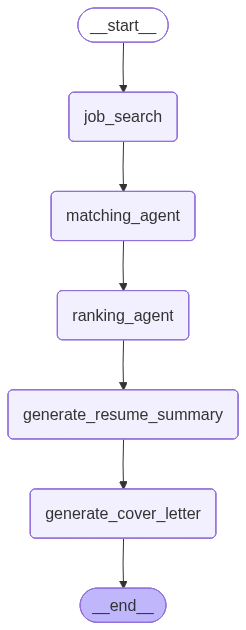

In [74]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [75]:
input_state = {
        "user_query": "data scientist"
}
result=app.invoke(input_state)

In [76]:
result['job_search']

[{'company': 'stripe',
  'title': 'Data Scientist',
  'location': 'Seattle, WA',
  'url': 'https://stripe.com/jobs/search?gh_jid=7809414',
  'description': '&lt;h2&gt;&lt;strong&gt;Who we are &lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;About Stripe&lt;/strong&gt;&lt;/h3&gt;\n&lt;p&gt;&lt;span style=&quot;font-weight: 400;&quot;&gt;Stripe is a financial infrastructure platform for businesses. Millions of companies - from the world’s largest enterprises to the most ambitious startups - use Stripe to accept payments, grow their revenue, and accelerate new business opportunities. Our mission is to increase the GDP of the internet, and we have a staggering amount of work ahead. That means you have an unprecedented opportunity to put the global economy within everyone&#39;s reach while doing the most important work of your career.&lt;/span&gt;&lt;/p&gt;\n&lt;h2&gt;&lt;strong&gt;What you’ll do&lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;Responsibilities&lt;/strong&gt;&lt;/h3&gt

In [77]:
from pprint import pprint
pprint((result['ranked_jobs']))

[{'company': 'stripe',
  'description': '&lt;h2&gt;&lt;strong&gt;Who we are '
                 '&lt;/strong&gt;&lt;/h2&gt;\n'
                 '&lt;h3&gt;&lt;strong&gt;About '
                 'Stripe&lt;/strong&gt;&lt;/h3&gt;\n'
                 '&lt;p&gt;&lt;span style=&quot;font-weight: '
                 '400;&quot;&gt;Stripe is a financial infrastructure platform '
                 'for businesses. Millions of companies - from the world’s '
                 'largest enterprises to the most ambitious startups - use '
                 'Stripe to accept payments, grow their revenue, and '
                 'accelerate new business opportunities. Our mission is to '
                 'increase the GDP of the internet, and we have a staggering '
                 'amount of work ahead. That means you have an unprecedented '
                 'opportunity to put the global economy within everyone&#39;s '
                 'reach while doing the most important work of your '
                 

In [78]:

pprint(result['resume_summary'])

('# Resume Summary\n'
 '\n'
 '**Data Scientist | Machine Learning & Analytics Professional**\n'
 '\n'
 "Results-driven Data Scientist with a Master's degree in Computer Science (or "
 'related quantitative field) and 3+ years of experience designing and '
 'deploying data-driven solutions at scale. Proven track record of building '
 'robust ETL data transformation pipelines in SQL and partnering '
 'cross-functionally with product, business, and sales teams to translate '
 'critical business questions into actionable insights. Brings 2+ years of '
 'hands-on experience productionalizing machine learning models and software '
 'products, applying advanced statistical, time series forecasting, and ML '
 'techniques to large datasets to predict user and product performance. Adept '
 'at designing, analyzing, and interpreting experiments; architecting scalable '
 'software systems; and launching end-to-end data science solutions using '
 'Python and R. Passionate about leveraging data to d

In [79]:
pprint(result['cover_letter'])

('# Cover Letter for Data Scientist Position at Stripe\n'
 '\n'
 '---\n'
 '\n'
 '**[Your Name]**\n'
 '[Your Address]\n'
 '[City, State, ZIP Code]\n'
 '[Email Address] | [Phone Number]\n'
 '[LinkedIn Profile URL]\n'
 '\n'
 '[Date]\n'
 '\n'
 'Stripe, Inc.\n'
 'Hiring Manager\n'
 '[Company Address]\n'
 '\n'
 '---\n'
 '\n'
 '**Re: Data Scientist Position**\n'
 '\n'
 'Dear Hiring Manager,\n'
 '\n'
 'I am writing to express my strong interest in the Data Scientist position at '
 "Stripe. As a results-driven data scientist with a Master's degree in "
 'Computer Science and over three years of experience building and deploying '
 'data-driven solutions at scale, I am excited by the opportunity to '
 "contribute to Stripe's mission of increasing the GDP of the internet and "
 'powering the financial infrastructure behind millions of businesses '
 'worldwide.\n'
 '\n'
 'Throughout my career, I have built a strong foundation in the exact skills '
 'this role demands. I have designed and built rob

In [32]:
class graphstate(TypedDict):
    resume_path:str
    resume_text:str
    extracted_data:dict
    

In [33]:
from langchain_community.document_loaders import PyPDFLoader

def load_pdf_agent(state:graphstate)->graphstate:
    resume_path=state['resume_path']
    loader = PyPDFLoader(resume_path)
    docs = loader.load()

    text = "\n".join(doc.page_content for doc in docs)
    return {**state,"resume_text":text}

In [34]:
import json
import re
from typing import Any, Dict

def resume_extraction_agent(state: graphstate) -> graphstate:
    prompt = f"""
    You are an information extraction system.

    Extract ALL useful information from the resume text below and return ONLY valid JSON.
    Do not add markdown, explanations, or code fences.

    Resume text:
    {state['resume_text']}

    Return this JSON structure:
    {{
      "personal_info": {{
        "name": "",
        "email": "",
        "phone": "",
        "linkedin": "",
        "github": "",
        "website": "",
        "location": ""
      }},
      "education": [
        {{
          "institute": "",
          "degree": "",
          "field": "",
          "cgpa_or_percentage": "",
          "start_date": "",
          "end_date": ""
        }}
      ],
      "experience": [
        {{
          "role": "",
          "company": "",
          "location": "",
          "start_date": "",
          "end_date": "",
          "highlights": []
        }}
      ],
      "projects": [
        {{
          "name": "",
          "description": "",
          "tech_stack": [],
          "links": {{
            "live": "",
            "github": ""
          }},
          "highlights": []
        }}
      ],
      "skills": {{
        "languages": [],
        "frameworks": [],
        "databases": [],
        "tools": [],
        "ai_ml": [],
        "cloud": []
      }},
      "certifications": [],
      "achievements": [],
      "summary": ""
    }}

    Rules:
    - If a field is missing, use an empty string or empty list.
    - Keep names and titles exactly as written in the resume when possible.
    - Return only JSON.
    """

    response = llm.invoke(prompt)
    raw_text = response.content.strip()

    # Try to clean common LLM formatting issues
    raw_text = re.sub(r"^```json\s*", "", raw_text)
    raw_text = re.sub(r"^```\s*", "", raw_text)
    raw_text = re.sub(r"\s*```$", "", raw_text)

    try:
        extracted_data: Dict[str, Any] = json.loads(raw_text)
    except json.JSONDecodeError:
        extracted_data = {
            "error": "Failed to parse JSON from model output",
            "raw_output": raw_text
        }

    return {
        **state,
        "extracted_data": extracted_data
    }

In [58]:
from langchain_core.documents import Document
from langchain_qdrant import QdrantVectorStore


def qdrant_store_agent(state: graphstate) -> graphstate:

    skills = state["extracted_data"]["skills"]
    experience = state["extracted_data"]["experience"]

    docs = [

        Document(
            page_content=json.dumps(skills),
            metadata={
                "section": "skills"
            }
        ),

        Document(
            page_content=json.dumps(experience),
            metadata={
                "section": "experience"
            }
        )

    ]

    QdrantVectorStore.from_documents(
        docs,
        embedding_model,
        path="./qdrant_db",
        collection_name="resume"
    )

    return state

In [59]:
workflow=StateGraph(graphstate)
workflow

In [60]:

workflow.add_node('load_pdf_agent',load_pdf_agent)
workflow.add_node('qdrant_store_agent',qdrant_store_agent)
workflow.add_node('resume_extraction_agent',resume_extraction_agent)
workflow.set_entry_point('load_pdf_agent')
workflow.add_edge('load_pdf_agent','resume_extraction_agent')
workflow.add_edge('resume_extraction_agent','qdrant_store_agent')
workflow.set_finish_point('qdrant_store_agent')

In [61]:
app=workflow.compile()

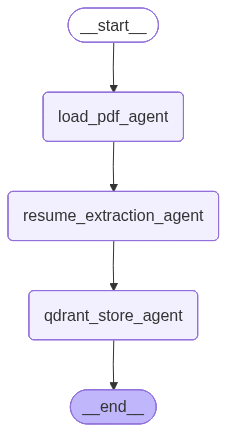

In [62]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [63]:
input_state = {
        "resume_path": "Software_Engineer_Resume__1_.pdf"
}
result=app.invoke(input_state)

In [64]:
result['extracted_data']

{'personal_info': {'name': 'Sourabh Bajaj',
  'email': 'mail@website.com',
  'phone': '+1-123-456-7890',
  'linkedin': '',
  'github': '',
  'website': 'http://www.sourabhbajaj.com',
  'location': 'Mountain View, CA'},
 'education': [{'institute': 'Georgia Institute of Technology',
   'degree': 'Master of Science',
   'field': 'Computer Science',
   'cgpa_or_percentage': '4.00',
   'start_date': 'Aug. 2012',
   'end_date': 'Dec. 2013'},
  {'institute': 'Birla Institute of Technology and Science',
   'degree': 'Bachelor of Engineering',
   'field': 'Electrical and Electronics',
   'cgpa_or_percentage': '3.66 (9.15/10.0)',
   'start_date': 'Aug. 2008',
   'end_date': 'July. 2012'}],
 'experience': [{'role': 'Software Engineer',
   'company': 'Google',
   'location': 'Mountain View, CA',
   'start_date': 'Oct 2016',
   'end_date': 'Present',
   'highlights': ['Tensorflow: TensorFlow is an open source software library for numerical computation using data flow graphs; primarily used for tra

In [ ]:
result['qu']